# Инференс и оценка конфигураций методов поиска

In [1]:
import sys, os, json, math, time, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

BASE_DIR = os.getcwd()
sys.path.insert(0, BASE_DIR)

ALL_METHODS = [
    #  Базовые (chunk_size=512, fixed) 
    ('tfidf',                    '',       'TF-IDF',                ''),
    ('bm25',                     '',       'BM25',                  ''),
    ('sbert',                    '',       'SBERT',                 ''),
    ('bge',                      '',       'BGE-M3',                ''),
    #  Sliding window (chunk_size=512, overlap=128) 
    ('tfidf',                    'window', 'TF-IDF+Window',         'window'),
    ('bm25',                     'window', 'BM25+Window',           'window'),
    ('sbert',                    'window', 'SBERT+Window',          'window'),
    ('bge',                      'window', 'BGE+Window',            'window'),
    #  Hybrid BM25-based 
    ('hybrid_sbert',             '',       'Hybrid SBERT',          ''),
    ('hybrid_bge',               '',       'Hybrid BGE',            ''),
    #  Hybrid TF-IDF+BGE  
    ('hybrid_tfidf_bge',         '',       'Hybrid TF-IDF+BGE',     ''),
    ('hybrid_tfidf_bge_k30',     '',       'Hybrid TF-IDF+BGE k30', ''),
    ('hybrid_tfidf_bge_weighted','',       'Hybrid TF-IDF+BGE w',   ''),
    #  HyDE 
    ('hyde_sbert',               '',       'HyDE+SBERT',            ''),
    ('hyde_bge',                 '',       'HyDE+BGE',              ''),
    #  chunk_size=256
     ('tfidf',                  'c256',   'TF-IDF c256',           'c256'),
     ('bm25',                   'c256',   'BM25 c256',             'c256'),
     ('bge',                    'c256',   'BGE-M3 c256',           'c256'),
     ('hybrid_tfidf_bge',       'c256',   'Hybrid TF-IDF+BGE c256','c256'),
]

K_VALUES = [1, 5, 10]

COLORS = [
    '#4C72B0','#DD8452','#55A868','#C44E52',
    '#8172B2','#937860','#DA8BC3','#8C8C8C',
    '#CCB974','#64B5CD','#4EAE4E','#B55C5C',
    '#E07B39','#6A9F5B','#9B59B6',
]


# Инференс

In [2]:
from search_03 import Retriever
from hybrid_04 import HybridRetriever, make_openai_llm

llm = make_openai_llm() 

_retriever_cache: dict = {}

def get_retriever(suffix: str) -> HybridRetriever:
    if suffix not in _retriever_cache:
        _retriever_cache[suffix] = HybridRetriever(
            suffix=suffix if suffix else None,
            window=False,
            llm_fn=llm    
        )
    return _retriever_cache[suffix]

print("Загружаем индексы базового чанкинга (512, fixed)...")
_ = get_retriever("")
print("\nЗагружаем индексы window чанкинга (512, overlap=128)...")
_ = get_retriever("window")
print("\nГотово.")


Загружаем индексы базового чанкинга (512, fixed)...
Загружаем базовые индексы...
TF-IDF (468 чанков)
BM25 (468 чанков)


/Users/evelinakurmanaeva/Documents/vkr/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6770.11it/s]


SBERT (468 векторов, dim=768)


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 100846.94it/s]


BGE-M3 (468 векторов, dim=1024)

Загружаем индексы window чанкинга (512, overlap=128)...
Загружаем базовые индексы...
TF-IDF (615 чанков)
BM25 (615 чанков)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7271.50it/s]


SBERT (615 векторов, dim=768)


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 96327.33it/s]


BGE-M3 (615 векторов, dim=1024)

Готово.


In [3]:
def load_qrels(filepath):
    """Загружает файл qrels. Возвращает пустой словарь если файл не найден."""
    if not os.path.exists(filepath):
        print(f"  [предупреждение] {filepath} не найден — пропускаем")
        return {}
    qrels = {}
    with open(filepath, encoding='utf-8') as f:
        for line in f:
            q   = json.loads(line)
            qid = q['query_id']
            if qid not in qrels:
                qrels[qid] = {'query': q['query'], 'relevant_ids': set()}
            qrels[qid]['relevant_ids'].add(q['chunk_id'])
    return qrels

def load_qrels_combined(suffix: str) -> dict:
    """Загружает и объединяет qrels + qrels_sud для заданного суффикса."""
    sfx = f"_{suffix}" if suffix else ""
    q1 = load_qrels(f'data/qrels{sfx}.jsonl')
    q2 = load_qrels(f'data/qrels_sud{sfx}.jsonl')
    return {**q1, **q2}

# Загружаем qrels для всех используемых суффиксов
used_suffixes = set(q for _,_,_,q in ALL_METHODS)
QRELS_MAP: dict[str, dict] = {}
for sfx in used_suffixes:
    QRELS_MAP[sfx] = load_qrels_combined(sfx)
    print(f"  qrels['{sfx}']: {len(QRELS_MAP[sfx])} запросов")

print(f"\nИтого суффиксов qrels: {len(QRELS_MAP)}")


  qrels['']: 106 запросов
  qrels['window']: 110 запросов
  qrels['c256']: 103 запросов

Итого суффиксов qrels: 3


Код показывает, какой метод поиска лучше находит ответ, показывая первый результат и score (мера релевантности документа запросу):

In [4]:
MY_QUERY = 'могут ли уволить на больничном?'
TOP_K = 5

print(f'Запрос: «{MY_QUERY}»\n')
print(f'{"Метод":<25} {"#":<4} {"chunk_id":<35} {"score":<8}')
print('─' * 80)

for method, idx_suffix, label, qrels_sfx in ALL_METHODS:
    try:
        ret = get_retriever(idx_suffix)
        results = ret.search(MY_QUERY, method, k=TOP_K)
        for i_r, r in enumerate(results[:1]):
            print(f'{label:<25} {i_r+1:<4} {r["chunk_id"]:<35} {r["score"]:.4f}')
    except Exception as e:
        print(f'{label:<25} [ошибка: {e}]')


Запрос: «могут ли уволить на больничном?»

Метод                     #    chunk_id                            score   
────────────────────────────────────────────────────────────────────────────────
TF-IDF                    1    sud_2_2025_2025_chunk_002           0.0418
BM25                      1    sud_2_4082_2025_chunk_003           7.6466
SBERT                     1    sud_2_4714_2025_chunk_001           0.6764
BGE-M3                    1    sud_2_2198_2025_chunk_002           0.6545
TF-IDF+Window             1    sud_2_2025_2025_chunk_002           0.0409
BM25+Window               1    sud_2_4082_2025_chunk_005           7.9578
SBERT+Window              1    sud_2_2025_2025_chunk_001           0.6768
BGE+Window                1    sud_2_2417_2025_chunk_002           0.6553
Hybrid SBERT              1    sud_2_4082_2025_chunk_003           0.0164
Hybrid BGE                1    sud_2_4082_2025_chunk_003           0.0164
Hybrid TF-IDF+BGE         1    sud_2_2025_2025_chunk_002    

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16259.53it/s]


SBERT (919 векторов, dim=768)


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 86469.10it/s]


BGE-M3 (919 векторов, dim=1024)
TF-IDF c256               1    sud_2_4082_2025_chunk_010           0.0631
BM25 c256                 1    sud_2_4082_2025_chunk_010           9.3878
BGE-M3 c256               1    sud_2_2198_2025_chunk_004           0.6619
Hybrid TF-IDF+BGE c256    1    sud_2_4082_2025_chunk_010           0.0164


In [6]:
# детальный вывод для одного метода
SHOW_METHOD = 'bge'       
SHOW_SUFFIX = ''          # суффикс индексов: "" / "window" / "c256" / "c256_window"
SHOW_QRELS  = ''         
EXAMPLE_IDX = 5       

qrels_for_show = QRELS_MAP.get(SHOW_QRELS, {})
qrels_list_show = list(qrels_for_show.values())

if EXAMPLE_IDX >= len(qrels_list_show):
    print(f"Индекс {EXAMPLE_IDX} выходит за пределы ({len(qrels_list_show)} запросов в qrels['{SHOW_QRELS}'])")
else:
    example = qrels_list_show[EXAMPLE_IDX]
    query = example['query']
    correct = example['relevant_ids']

    ret = get_retriever(SHOW_SUFFIX)
    results = ret.search(query, SHOW_METHOD, k=10)

    suffix_label = f" (suffix='{SHOW_SUFFIX}')" if SHOW_SUFFIX else ""
    print(f'Запрос: «{query}»')
    print(f'Метод:  {SHOW_METHOD.upper()}{suffix_label}')
    print(f'Релевантных чанков: {len(correct)}')
    print('─' * 70)
    for i, r in enumerate(results):
        mark = '✅ Верно ' if r['chunk_id'] in correct else '❌ Неверно'
        text = ret.get_chunk_text(r['chunk_id'])
        print(f'{mark} [{i+1:2d}] {r["chunk_id"]:<35} score={r["score"]:.4f}')
        print(f'       {text[:200]}...')
        print()

    print('Правильный ответ:')
    for cid in correct:
        found_at = next((i+1 for i, r in enumerate(results) if r['chunk_id'] == cid), None)
        rank_str = f"  ← найден на позиции {found_at}" if found_at else "  ← НЕ найден в топ-10"
        print(f'[{cid}]{rank_str}')
        print(ret.get_chunk_text(cid)[:300])
        print()

Запрос: «может ли работодатель установить свои правила которые хуже чем в трудовом кодексе?»
Метод:  BGE
Релевантных чанков: 1
──────────────────────────────────────────────────────────────────────
❌ Неверно [ 1] tk_rf_chunk_120                     score=0.6128
       работодателем - физическим лицом. При этом продолжительность рабочей недели не может быть больше, а продолжительность ежегодного оплачиваемого отпуска меньше, чем установленные настоящим Кодексом. Ста...

❌ Неверно [ 2] tk_rf_chunk_003                     score=0.6037
       в процессе трудовой деятельности); обеспечиваемый государством уровень трудовых прав, свобод и гарантий работникам (включая дополнительные гарантии отдельным категориям работников); порядок заключения...

✅ Верно  [ 3] tk_rf_chunk_004                     score=0.5960
       соблюдения установленного статьей 372 настоящего Кодекса порядка учета мнения представительного органа работников, не подлежат применению. В таких случаях применяются трудовое зако

### Рассмотрим детальнее правильный ответ (красным выделена часть, которая отвечает на вопрос пользователя):

'соблюдения установленного статьей 372 настоящего Кодекса порядка учета мнения представительного органа работников, не подлежат применению. В таких случаях применяются трудовое законодательство и иные нормативные правовые акты, содержащие нормы трудового права, коллективный договор, соглашения. Статья 9. Регулирование трудовых отношений и иных непосредственно связанных с ними отношений в договорном порядке В соответствии с трудовым законодательством регулирование трудовых отношений и иных непосредственно связанных с ними отношений может осуществляться путем заключения, изменения, дополнения работниками и работодателями коллективных договоров, соглашений, трудовых договоров. <span style="color:red;">Коллективные договоры, соглашения, трудовые договоры не могут содержать условий, ограничивающих права или снижающих уровень гарантий работников по сравнению с установленными трудовым законодательством и иными нормативными правовыми актами, содержащими нормы трудового права.</span> Если такие условия включены в коллективный договор, соглашение или трудовой договор, то они не подлежат применению. Статья 10. Трудовое законодательство, иные акты, содержащие нормы трудового права, и нормы международного права Общепризнанные принципы и нормы международного права и международные договоры Российской Федерации в соответствии с Конституцией Российской Федерации являются составной частью правовой системы Российской Федерации. Если международным договором Российской Федерации установлены другие правила, чем предусмотренные трудовым законодательством и иными актами, содержащими нормы трудового права, применяются правила международного договора. Не допускается применение правил международных договоров Российской Федерации в их истолковании, противоречащем Конституции Российской Федерации. Такое противоречие может быть установлено в порядке, определенном федеральным конституционным законом. Статья 11. Действие трудового законодательства и иных актов, содержащих нормы трудового права Трудовым законодательством и иными актами, содержащими нормы трудового права, регулируются трудовые отношения и иные непосредственно связанные с ними отношения. Трудовое законодательство и иные акты, содержащие нормы трудового права, также применяются к другим отношениям, связанным с использованием личного труда, если это предусмотрено настоящим Кодексом или иным федеральным законом. Все работодатели (физические лица и юридические лица, независимо от их организационно-правовых форм и форм собственности) в трудовых отношениях и иных непосредственно связанных с ними отношениях с работниками обязаны руководствоваться положениями трудового законодательства и иных актов, содержащих нормы трудового права. Если отношения, связанные с использованием личного труда, возникли на основании гражданско-правового договора, но впоследствии в порядке, установленном настоящим Кодексом, другими федеральными законами, были признаны трудовыми отношениями, к таким отношениям применяются положения трудового законодательства и иных актов, содержащих нормы трудового права. На территории Российской Федерации правила, установленные трудовым законодательством и иными актами, содержащими нормы трудового права, распространяются на трудовые отношения с участием иностранных граждан, лиц без гражданства, организаций, созданных или учрежденных иностранными гражданами, лицами без гражданства либо с их участием, международных организаций и иностранных юридических лиц, если иное не предусмотрено настоящим Кодексом, другими федеральными законами или международным договором Российской Федерации. Особенности правового регулирования труда отдельных категорий работников (руководителей организаций, лиц, работающих по совместительству, женщин, лиц с семейными обязанностями, молодежи и других) устанавливаются в соответствии с настоящим Кодексом. На государственных служащих и муниципальных служащих действие трудового законодательства и иных актов, содержащих нормы трудового права, распространяется с особенностями, предусмотренными федеральными законами и иными нормативными правовыми актами Российской Федерации, законами и иными нормативными правовыми актами субъектов Российской Федерации о государственной службе и муниципальной службе. Трудовое законодательство и иные акты, содержащие нормы трудового права, не распространяются на следующих лиц (если в установленном настоящим Кодексом порядке они одновременно не выступают в качестве работодателей или их представителей): военнослужащие при исполнении'


# Evaluation 

In [7]:
def recall_at_k(rel, res, k):
    return 1.0 if rel & {r['chunk_id'] for r in res[:k]} else 0.0

def precision_at_k(rel, res, k):
    hits = sum(1 for r in res[:k] if r['chunk_id'] in rel)
    return hits / k

def mrr(rel, res):
    for i, r in enumerate(res):
        if r['chunk_id'] in rel:
            return 1.0/(i+1)
    return 0.0

def ndcg_at_k(rel, res, k):
    for i, r in enumerate(res[:k]):
        if r['chunk_id'] in rel:
            return (1/math.log2(i+2))/(1/math.log2(2))
    return 0.0

Прогоняем все конфигурации:

In [8]:
all_results = {}
k_max = max(K_VALUES)

for method, idx_suffix, label, qrels_sfx in ALL_METHODS:
    qrels = QRELS_MAP.get(qrels_sfx, {})
    if not qrels:
        print(f"{label:<25} [пропуск: нет qrels для суффикса '{qrels_sfx}']")
        continue

    try:
        ret = get_retriever(idx_suffix)
    except Exception as e:
        print(f"{label:<25} [пропуск: нет индексов — {e}]")
        continue

    metrics = defaultdict(list)
    times = []

    for qdata in qrels.values():
        query = qdata['query']
        rel = qdata['relevant_ids']

        t0 = time.perf_counter()
        results = ret.search(query, method, k=k_max)
        times.append((time.perf_counter()-t0)*1000)

        for k in K_VALUES:
            metrics[f'recall@{k}'].append(recall_at_k(rel, results, k))
            metrics[f'precision@{k}'].append(precision_at_k(rel, results, k))
            metrics[f'ndcg@{k}'].append(ndcg_at_k(rel, results, k))
        metrics['mrr'].append(mrr(rel, results))

    avg = {key: round(sum(v)/len(v), 4) for key,v in metrics.items()}
    avg['time_ms'] = round(float(np.mean(times)), 2)
    avg['label'] = label
    all_results[label] = avg

    print(f"{label:<25} MRR={avg['mrr']:.3f}  R@5={avg['recall@5']:.3f}  "
          f"NDCG@5={avg['ndcg@5']:.3f}  t={avg['time_ms']}мс")


TF-IDF                    MRR=0.219  R@5=0.340  NDCG@5=0.230  t=1.3мс
BM25                      MRR=0.185  R@5=0.311  NDCG@5=0.202  t=0.4мс
SBERT                     MRR=0.121  R@5=0.179  NDCG@5=0.126  t=17.71мс
BGE-M3                    MRR=0.438  R@5=0.641  NDCG@5=0.477  t=21.16мс
TF-IDF+Window             MRR=0.225  R@5=0.336  NDCG@5=0.237  t=1.59мс
BM25+Window               MRR=0.204  R@5=0.327  NDCG@5=0.225  t=0.58мс
SBERT+Window              MRR=0.186  R@5=0.255  NDCG@5=0.195  t=10.47мс
BGE+Window                MRR=0.448  R@5=0.609  NDCG@5=0.473  t=21.54мс
Hybrid SBERT              MRR=0.230  R@5=0.340  NDCG@5=0.247  t=10.31мс
Hybrid BGE                MRR=0.380  R@5=0.538  NDCG@5=0.403  t=18.16мс
Hybrid TF-IDF+BGE         MRR=0.388  R@5=0.566  NDCG@5=0.418  t=18.1мс
Hybrid TF-IDF+BGE k30     MRR=0.388  R@5=0.566  NDCG@5=0.418  t=18.29мс
Hybrid TF-IDF+BGE w       MRR=0.419  R@5=0.651  NDCG@5=0.467  t=18.15мс
HyDE+SBERT                MRR=0.109  R@5=0.160  NDCG@5=0.118  t=2862.11

In [ ]:
rows = []
for method, idx_suffix, label, qrels_sfx in ALL_METHODS:
    if label not in all_results:
        continue
    m = all_results[label]
    row = {'Метод': label}
    for k in K_VALUES:
        row[f'R@{k}'] = m[f'recall@{k}']
        row[f'P@{k}'] = m[f'precision@{k}']
        row[f'NDCG@{k}'] = m[f'ndcg@{k}']
    row['MRR'] = m['mrr']
    row['Время (мс)'] = m['time_ms']
    rows.append(row)

df = pd.DataFrame(rows).set_index('Метод')
df.style.highlight_max(subset=['MRR','R@5','NDCG@10'], color='lightgreen')
df


,R@1,P@1,NDCG@1,R@5,P@5,NDCG@5,R@10,P@10,NDCG@10,MRR,Время (мс)
Метод,,,,,,,,,,,
TF-IDF,0.1038,0.1038,0.1038,0.3396,0.0698,0.2295,0.5283,0.0547,0.2911,0.2186,1.25
BM25,0.0943,0.0943,0.0943,0.3113,0.0642,0.2021,0.4528,0.0472,0.2478,0.1851,0.34
SBERT,0.0755,0.0755,0.0755,0.1792,0.0358,0.1255,0.2830,0.0292,0.1585,0.1215,10.57
BGE-M3,0.3113,0.3113,0.3113,0.6415,0.1321,0.4775,0.7453,0.0764,0.5116,0.4380,19.01
TF-IDF+Window,0.1273,0.1273,0.1273,0.3364,0.0800,0.2374,0.4818,0.0600,0.2853,0.2249,1.62
BM25+Window,0.1091,0.1091,0.1091,0.3273,0.0782,0.2245,0.4273,0.0518,0.2575,0.2043,0.53
SBERT+Window,0.1273,0.1273,0.1273,0.2545,0.0509,0.1952,0.3455,0.0382,0.2236,0.1865,9.91
BGE+Window,0.3182,0.3182,0.3182,0.6091,0.1527,0.4733,0.7545,0.0918,0.5209,0.4480,20.62
Hybrid SBERT,0.1509,0.1509,0.1509,0.3396,0.0679,0.2475,0.4434,0.0462,0.2803,0.2304,10.32


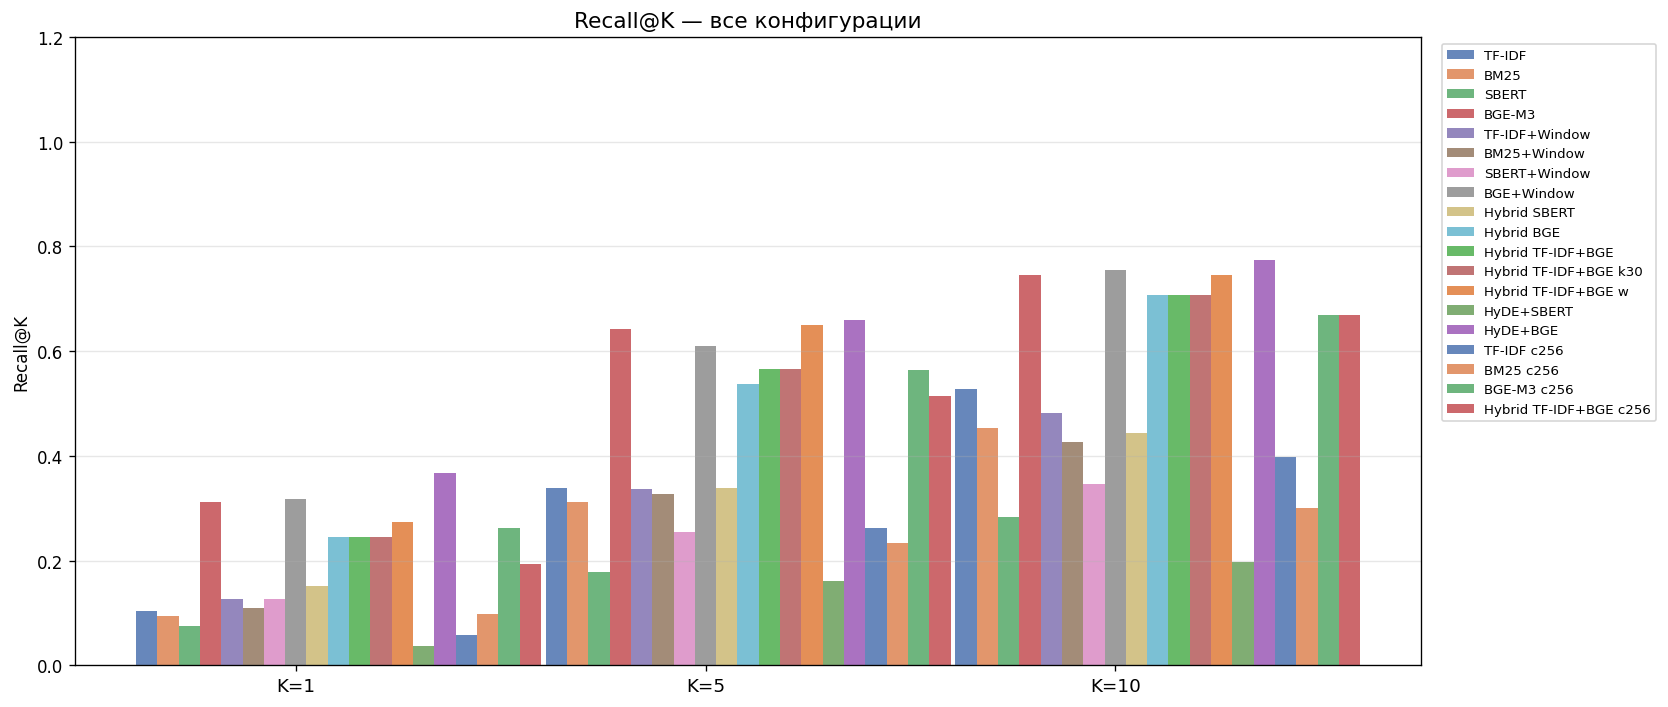

In [ ]:
# Recall@K
labels = [label for _,_,label,_ in ALL_METHODS if label in all_results]
x = np.arange(len(K_VALUES))
width = 0.052

fig, ax = plt.subplots(figsize=(14, 6))
for i, label in enumerate(labels):
    vals = [all_results[label][f'recall@{k}'] for k in K_VALUES]
    ax.bar(x + i*width, vals, width, label=label, color=COLORS[i % len(COLORS)], alpha=0.85)

ax.set_xticks(x + width*7)
ax.set_xticklabels([f'K={k}' for k in K_VALUES], fontsize=11)
ax.set_ylim(0, 1.2)
ax.set_ylabel('Recall@K')
ax.set_title('Recall@K — все конфигурации', fontsize=13)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('data/plot_recall_all.png', bbox_inches='tight')
plt.show()

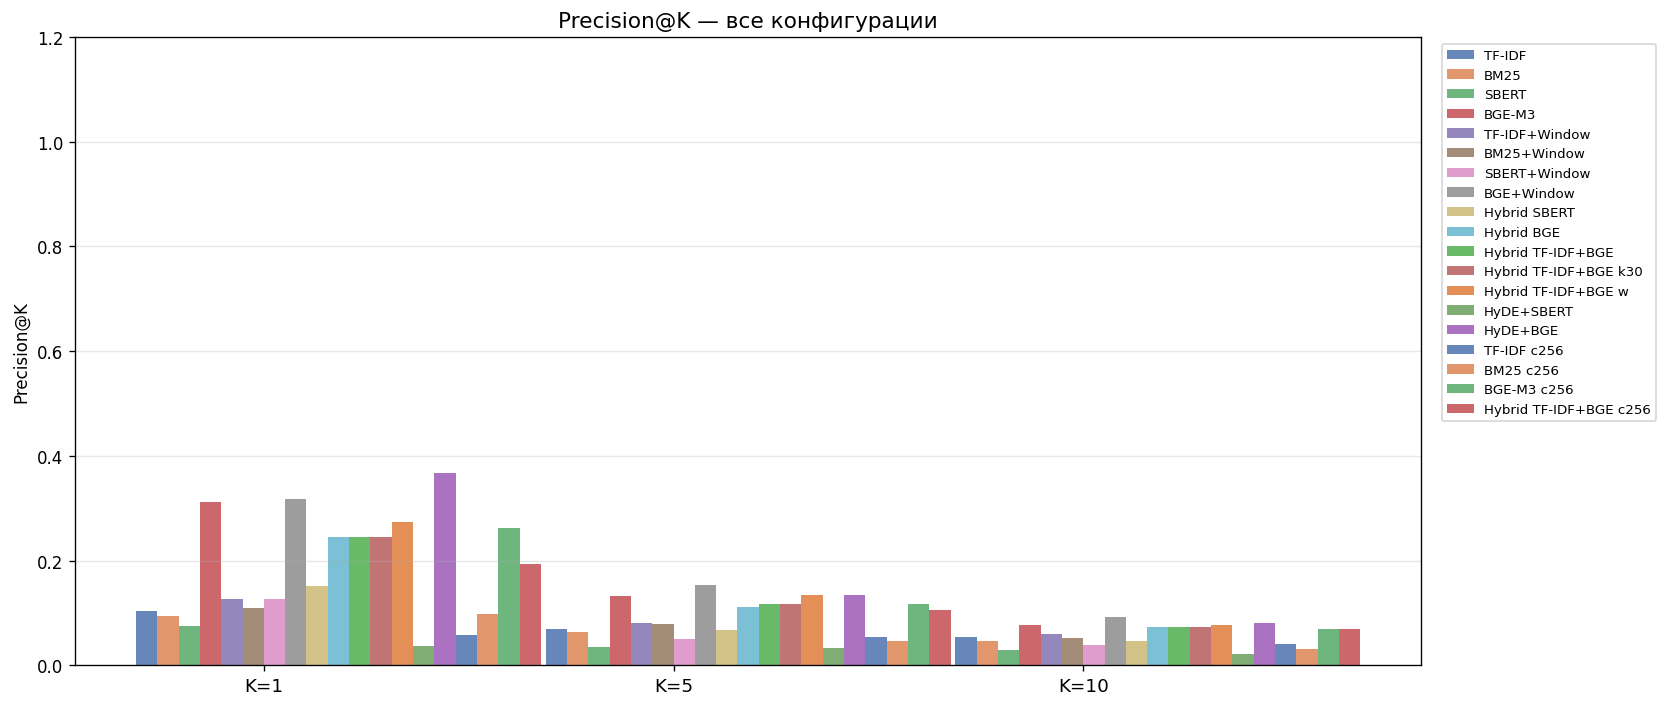

In [ ]:
# Precision@K 
fig, ax = plt.subplots(figsize=(14, 6))
for i, label in enumerate(labels):
    vals = [all_results[label][f'precision@{k}'] for k in K_VALUES]
    ax.bar(x + i*width, vals, width, label=label, color=COLORS[i % len(COLORS)], alpha=0.85)

ax.set_xticks(x + width*5.5)
ax.set_xticklabels([f'K={k}' for k in K_VALUES], fontsize=11)
ax.set_ylim(0, 1.2)
ax.set_ylabel('Precision@K')
ax.set_title('Precision@K — все конфигурации', fontsize=13)
ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('data/plot_precision_all.png', bbox_inches='tight')
plt.show()

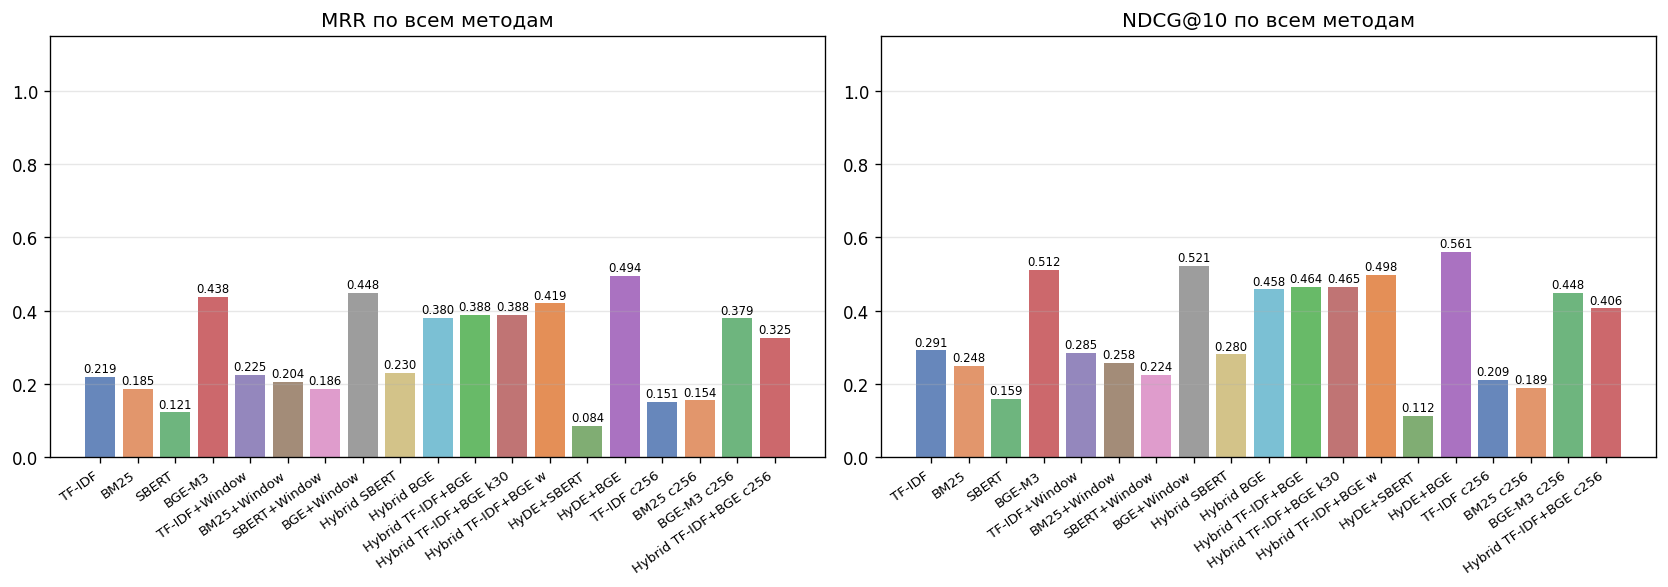

In [ ]:
# MRR и NDCG@10 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, key, title in [
    (axes[0], 'mrr', 'MRR по всем методам'),
    (axes[1], 'ndcg@10', 'NDCG@10 по всем методам'),
]:
    vals = [all_results[l][key] for l in labels]
    bars = ax.bar(range(len(labels)), vals, color=COLORS[:len(labels)], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.set_title(title, fontsize=12)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('data/plot_mrr_ndcg.png', bbox_inches='tight')
plt.show()

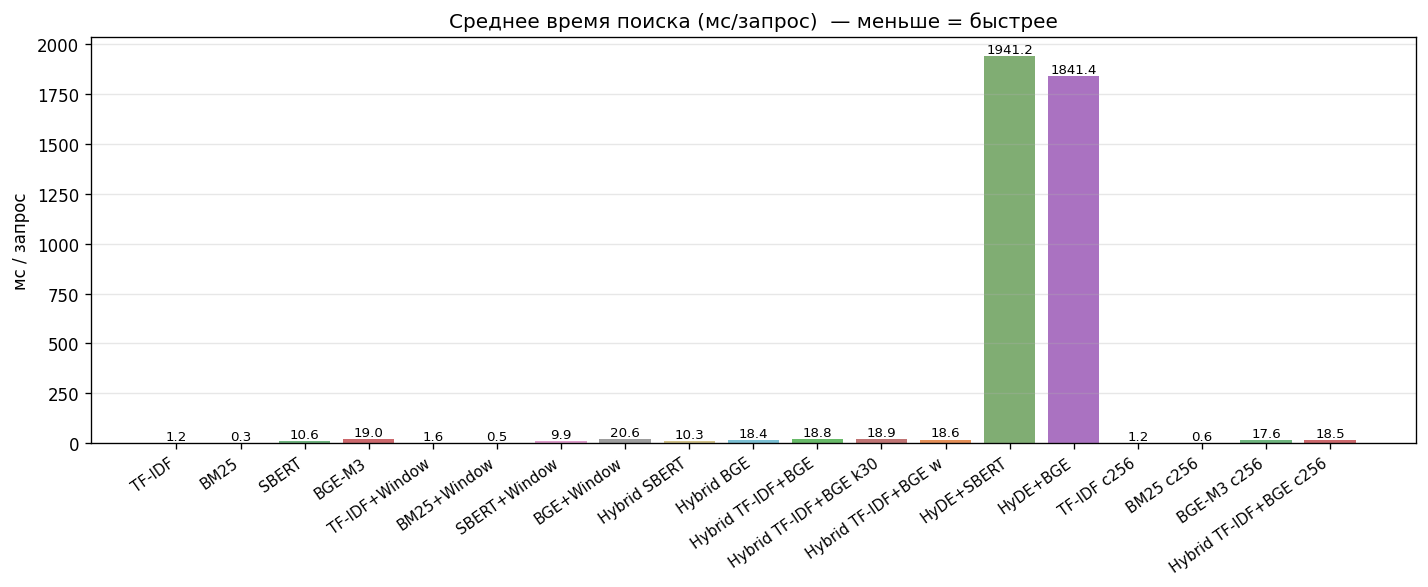

In [29]:
# время работы 
times = [all_results[l]['time_ms'] for l in labels]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(labels)), times, color=COLORS[:len(labels)], alpha=0.85)
for bar, v in zip(bars, times):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{v:.1f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('мс / запрос')
ax.set_title('Среднее время поиска (мс/запрос)  — меньше = быстрее', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('data/plot_time_all.png', bbox_inches='tight')
plt.show()

In [30]:
with open('data/eval_results.json','w',encoding='utf-8') as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)
print('Результаты → data/eval_results.json')
print('Графики    → data/plot_*.png')

Результаты → data/eval_results.json
Графики    → data/plot_*.png
